In [1]:
# !pip uninstall -y openai langchain-openai langchain langgraph
# !pip install openai==1.43.0 langchain==0.2.14 langchain-openai==0.1.22 langgraph==0.2.22


Found existing installation: openai 2.9.0
Uninstalling openai-2.9.0:
  Successfully uninstalled openai-2.9.0
Found existing installation: langchain 1.1.3
Uninstalling langchain-1.1.3:
  Successfully uninstalled langchain-1.1.3
Found existing installation: langgraph 1.0.4
Uninstalling langgraph-1.0.4:
  Successfully uninstalled langgraph-1.0.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.7/365.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.8/997.8 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [1]:
# Uninstall conflicting packages
!pip uninstall -y openai httpx langchain langchain-openai langgraph

# Install compatible versions
!pip install -U --force-reinstall \
  "httpx==0.27.2" \
  "openai>=1.55.3,<2" \
  "langchain==0.2.14" \
  "langchain-openai==0.1.22" \
  "langgraph==0.2.22" \
  "pandas>=2.0.0" \
  "numpy>=1.24.0" \
  "matplotlib>=3.7.0" \
  "openpyxl>=3.1.0" \
  "python-dotenv>=1.0.0"

Found existing installation: openai 1.43.0
Uninstalling openai-1.43.0:
  Successfully uninstalled openai-1.43.0
Found existing installation: httpx 0.28.1
Uninstalling httpx-0.28.1:
  Successfully uninstalled httpx-0.28.1
Found existing installation: langchain 0.2.14
Uninstalling langchain-0.2.14:
  Successfully uninstalled langchain-0.2.14
Found existing installation: langchain-openai 0.1.22
Uninstalling langchain-openai-0.1.22:
  Successfully uninstalled langchain-openai-0.1.22
Found existing installation: langgraph 0.2.22
Uninstalling langgraph-0.2.22:
  Successfully uninstalled langgraph-0.2.22
  Using cached langchain-0.2.14-py3-none-any.whl.metadata (7.1 kB)
  Using cached langchain_openai-0.1.22-py3-none-any.whl.metadata (2.6 kB)
  Using cached langgraph-0.2.22-py3-none-any.whl.metadata (13 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

🚀 EDA Agent - Production Grade
✓ Loaded dataset: 20 rows × 10 columns (0.01 MB)
⚙ Generating statistics...
✓ Statistics generated for 10 columns
📊 Generating visualizations...
✓ Generated 15 charts → /content/output/charts


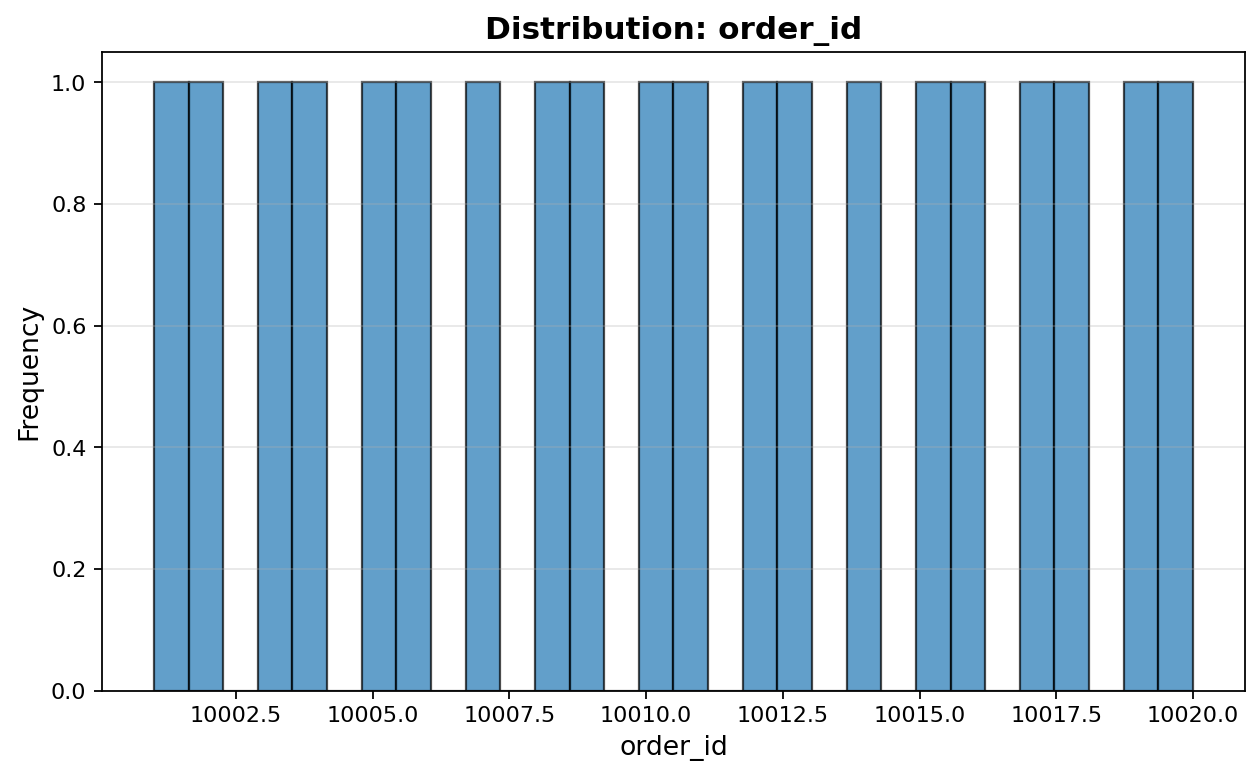

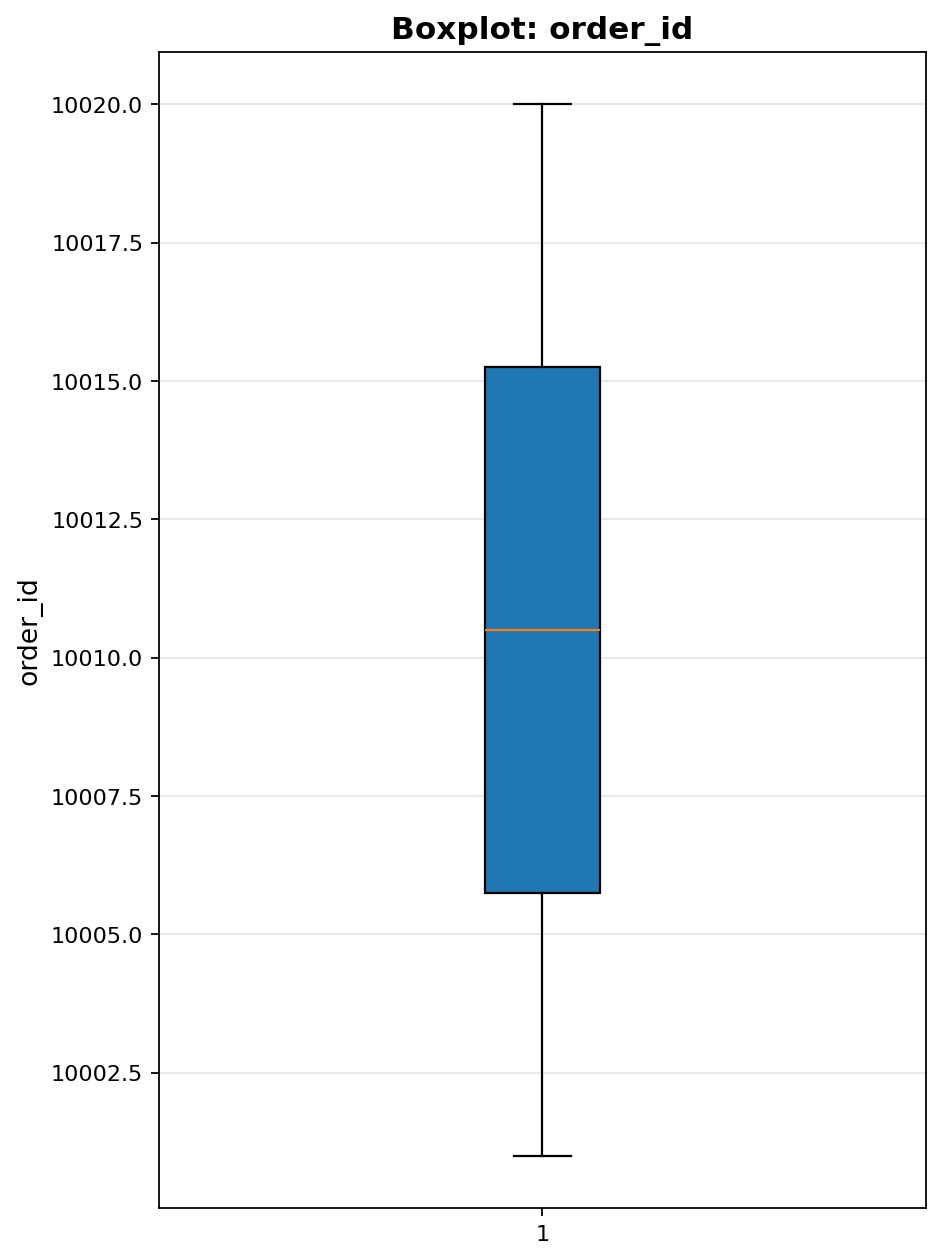

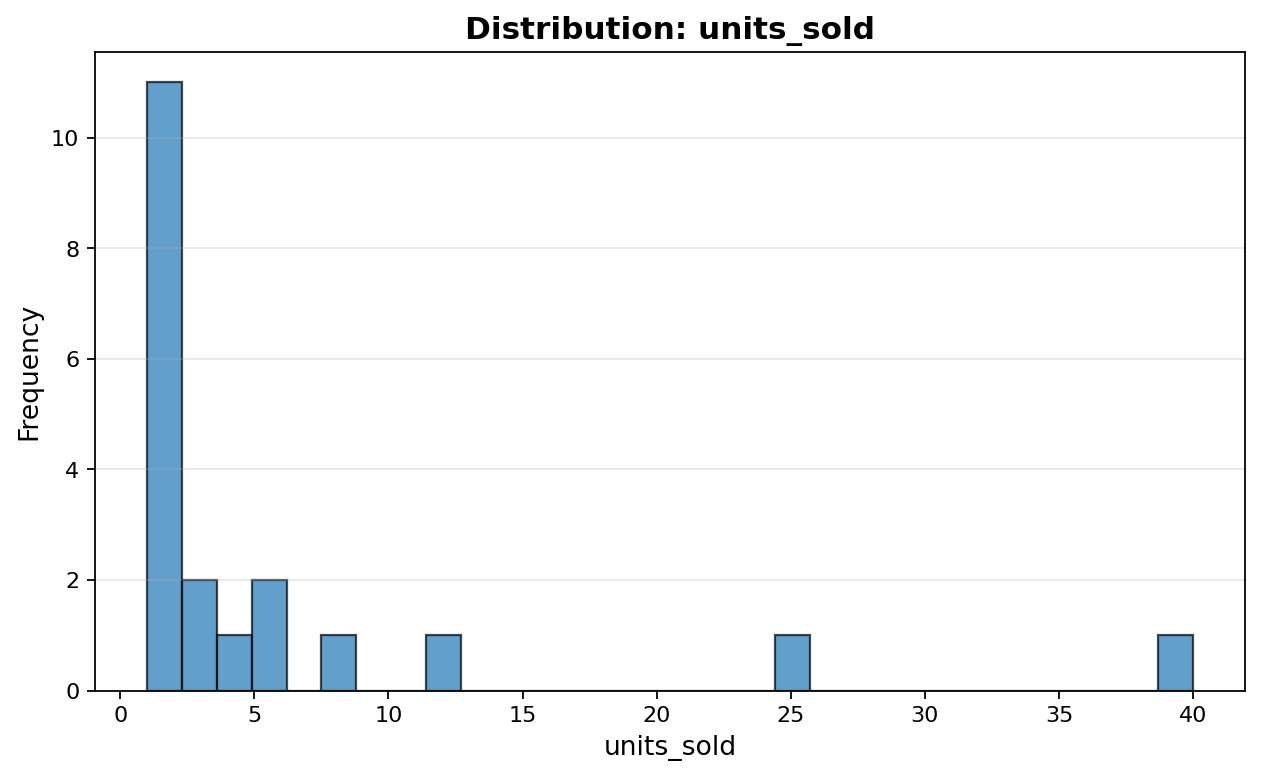

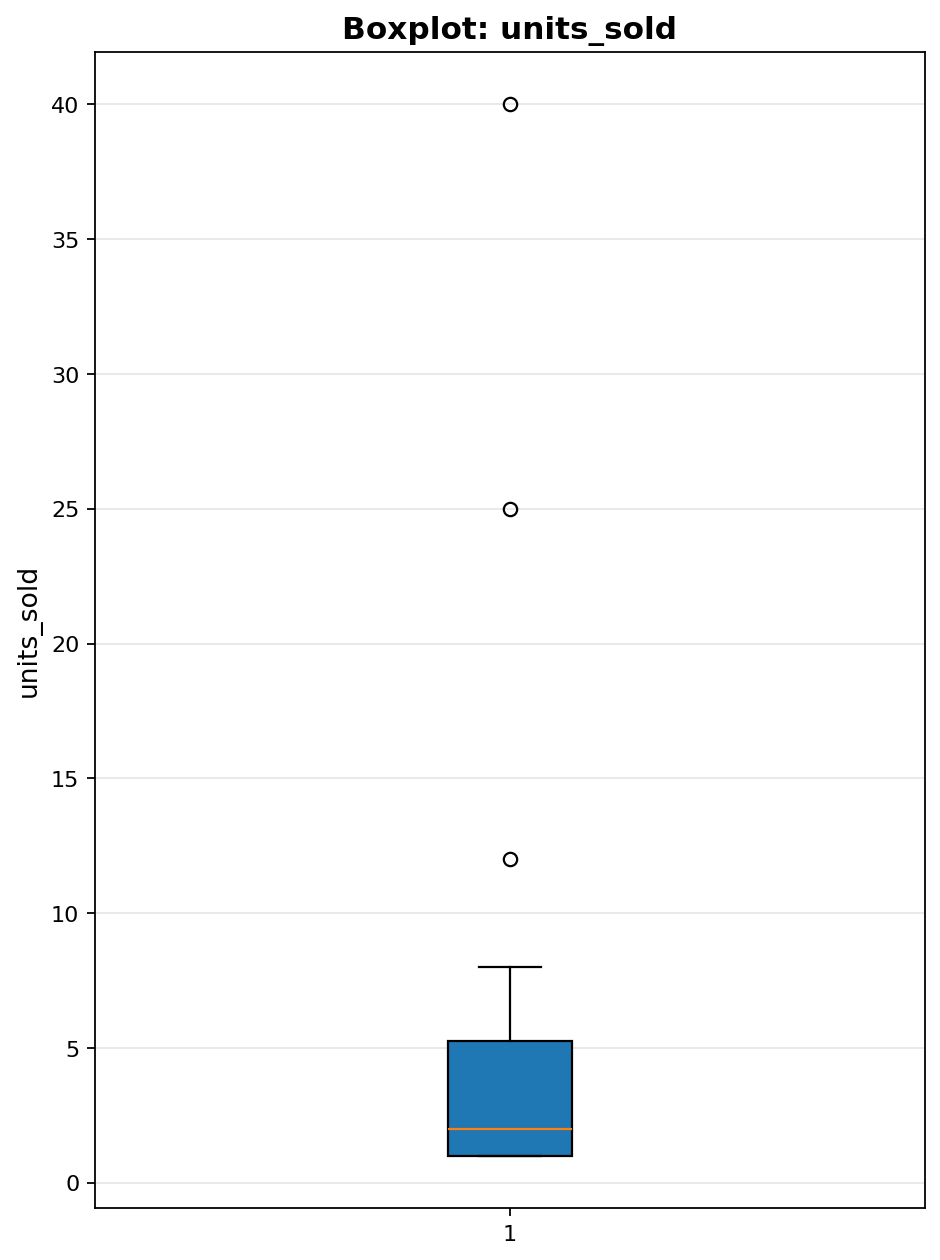

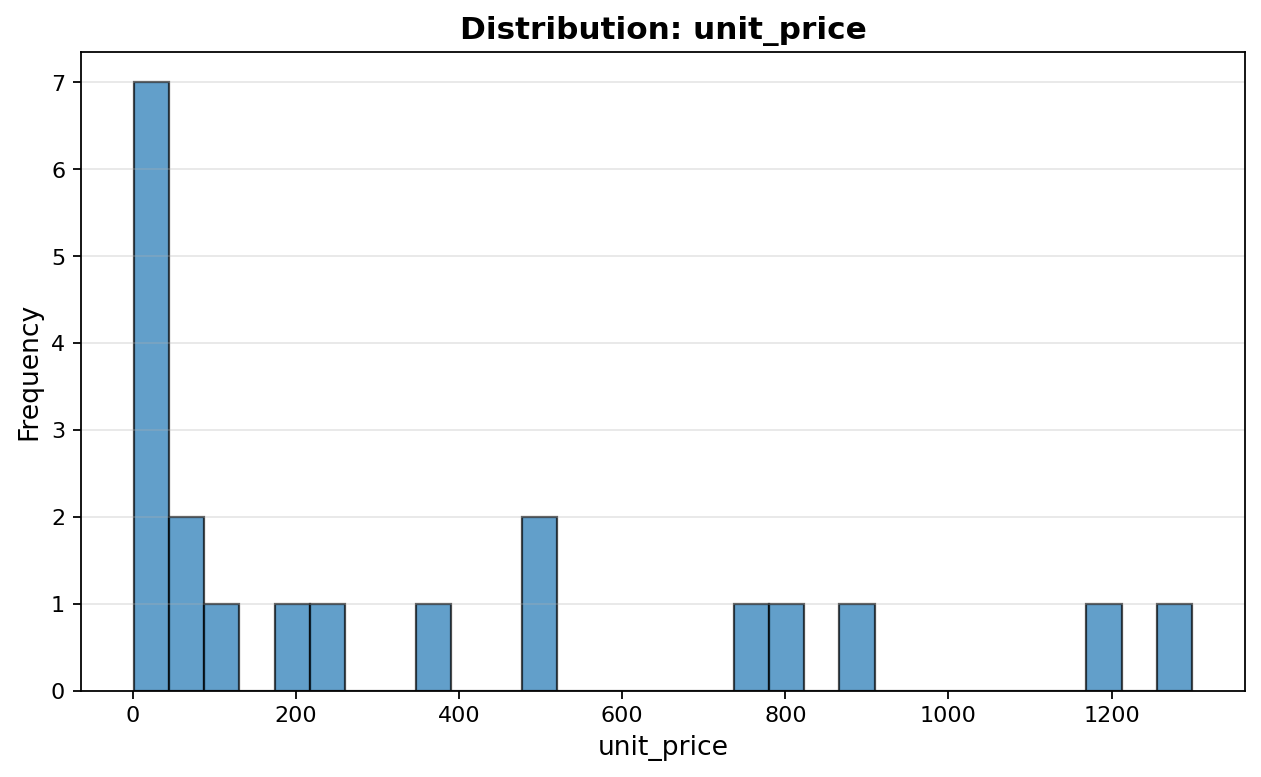

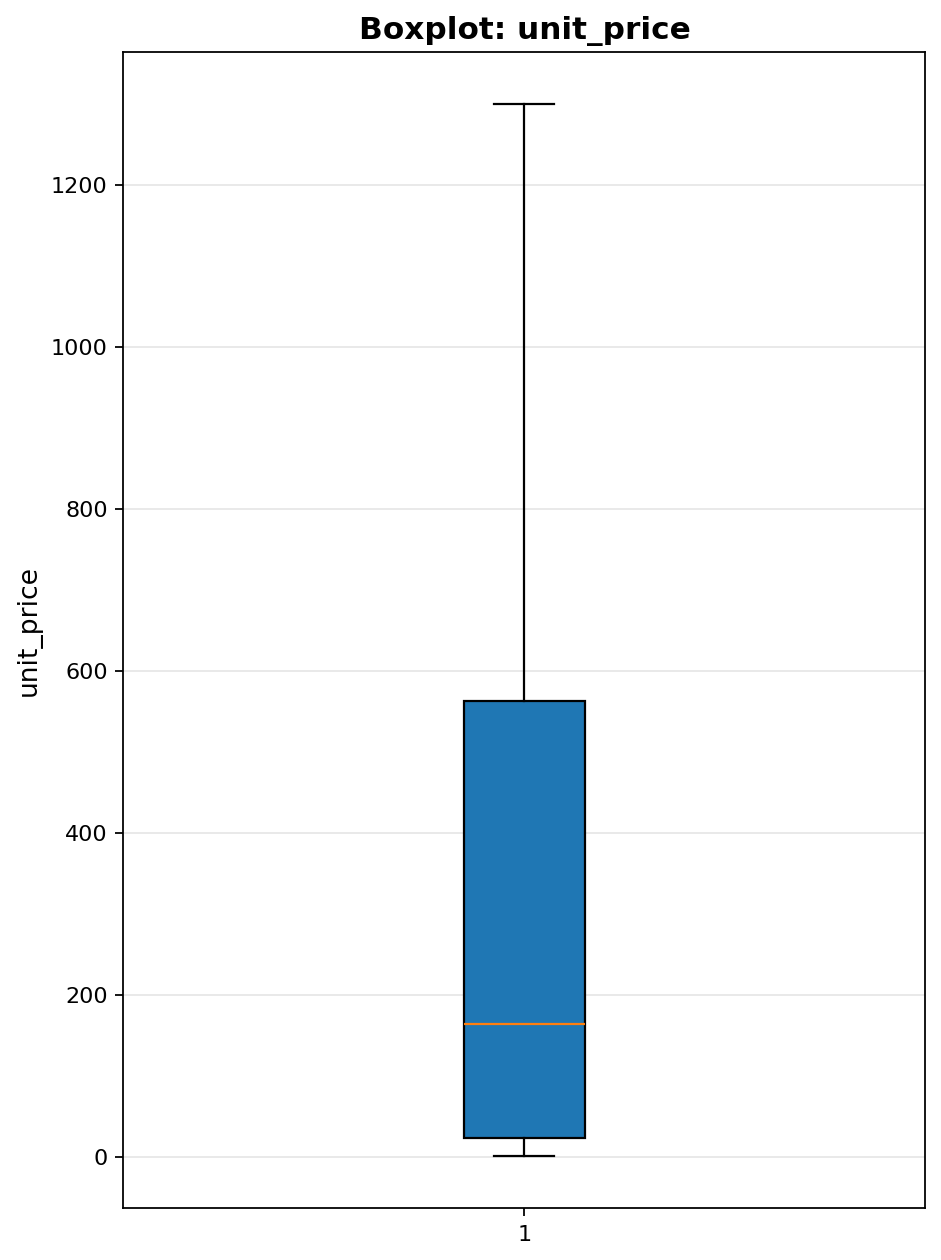

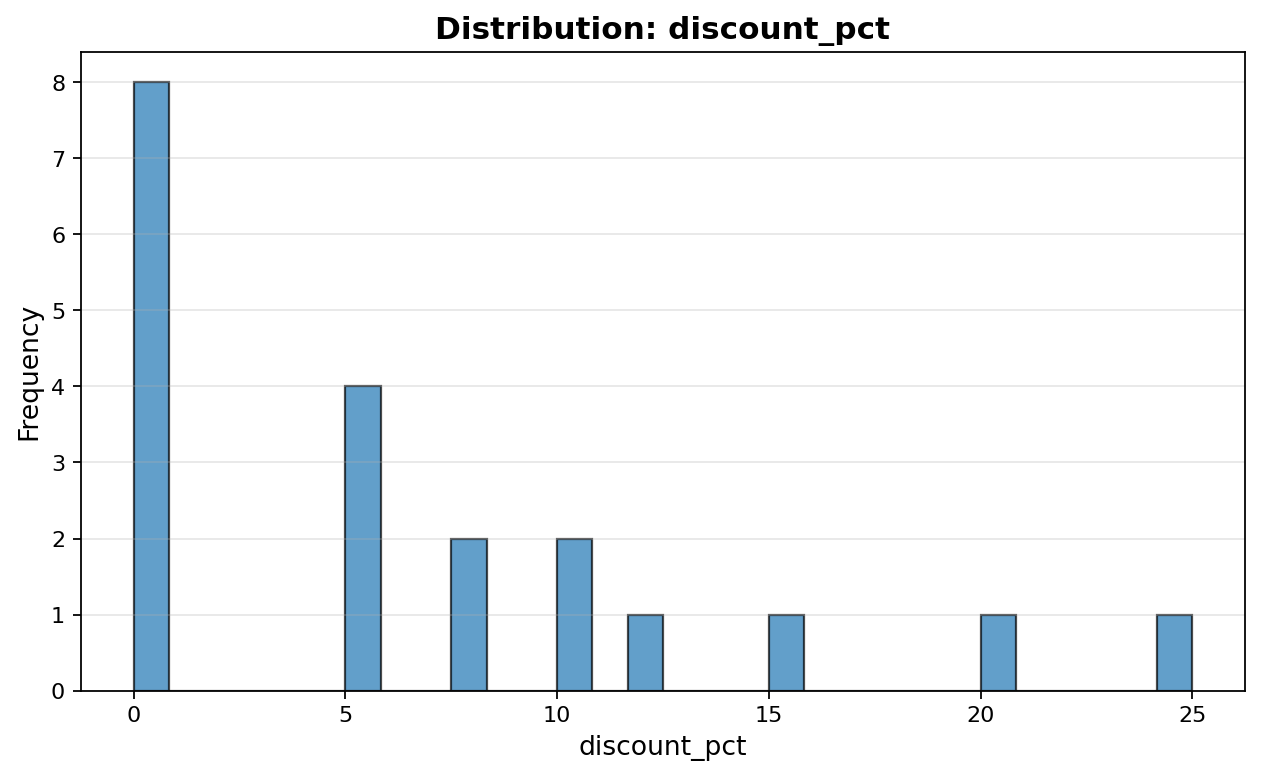

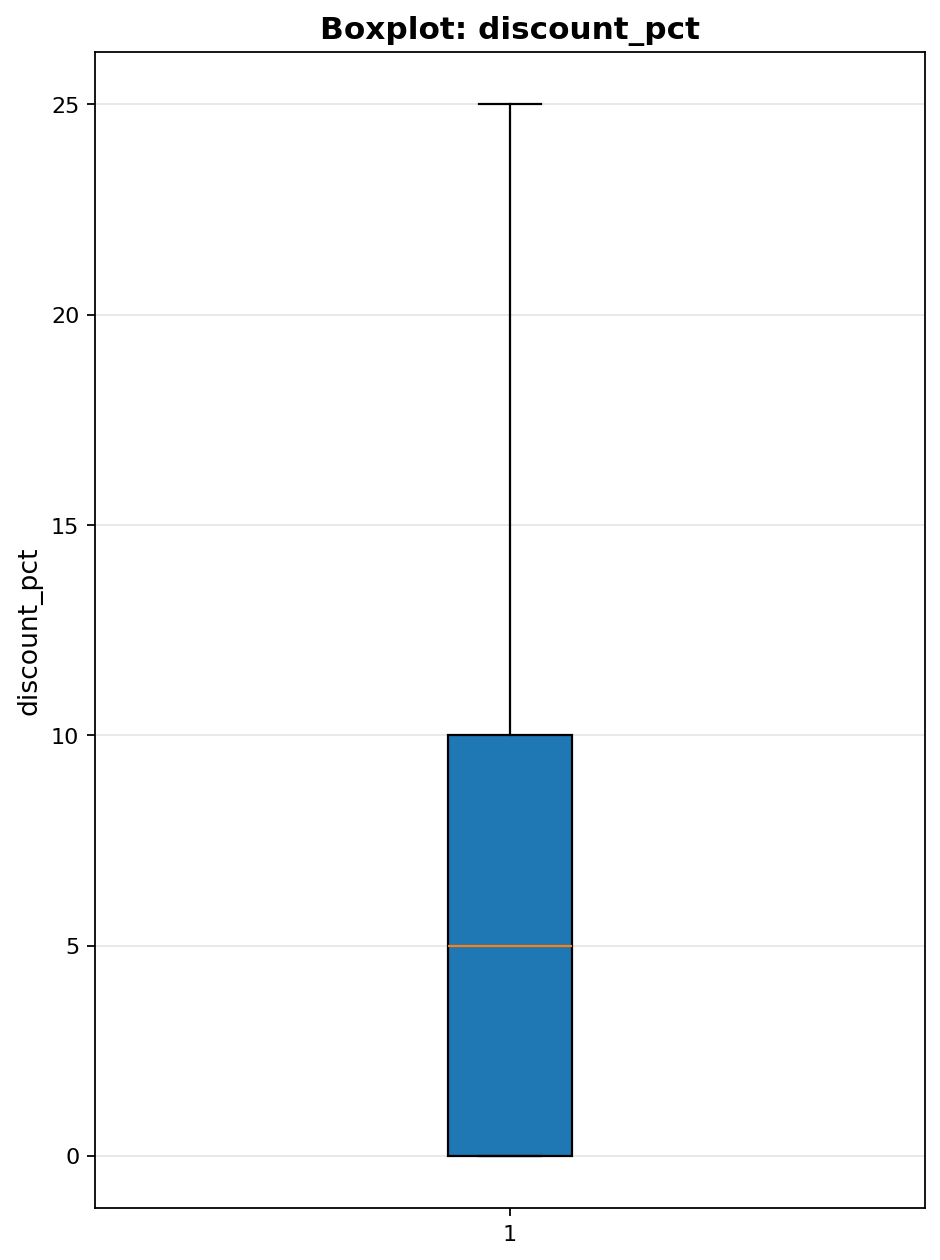

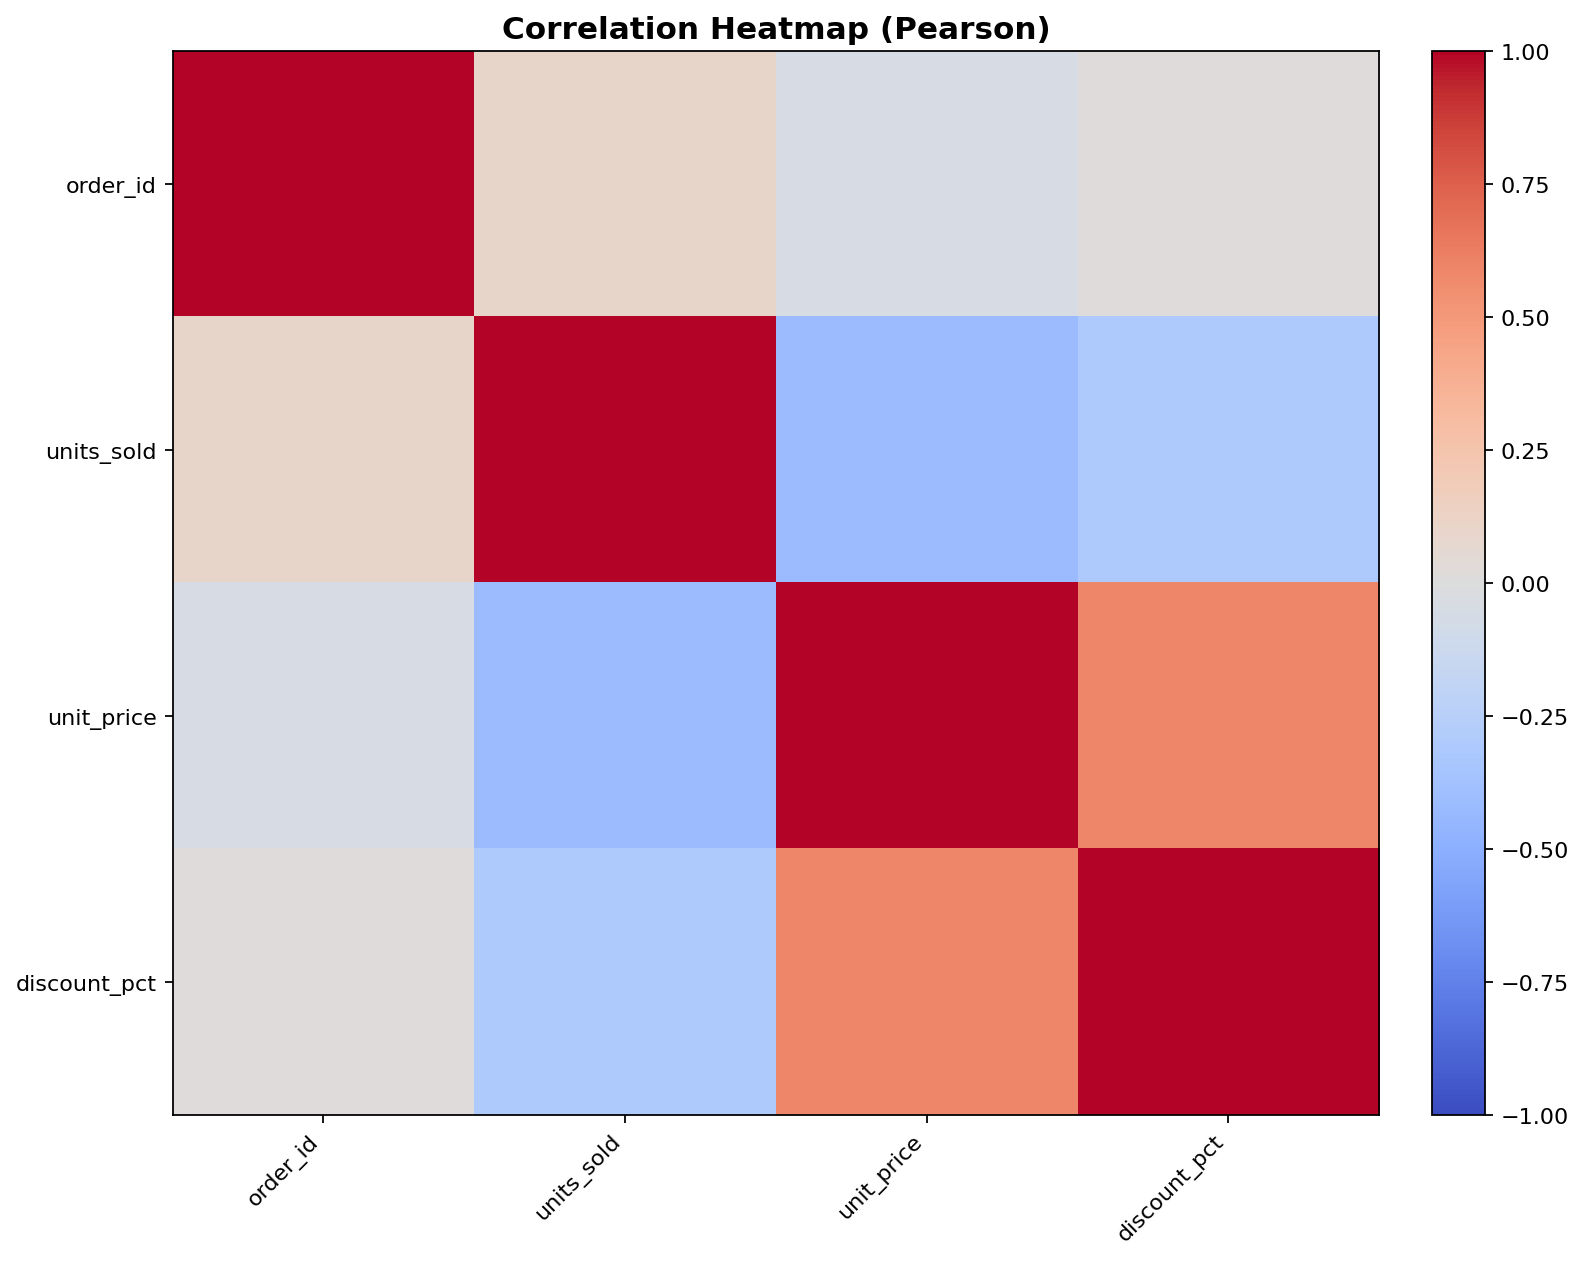

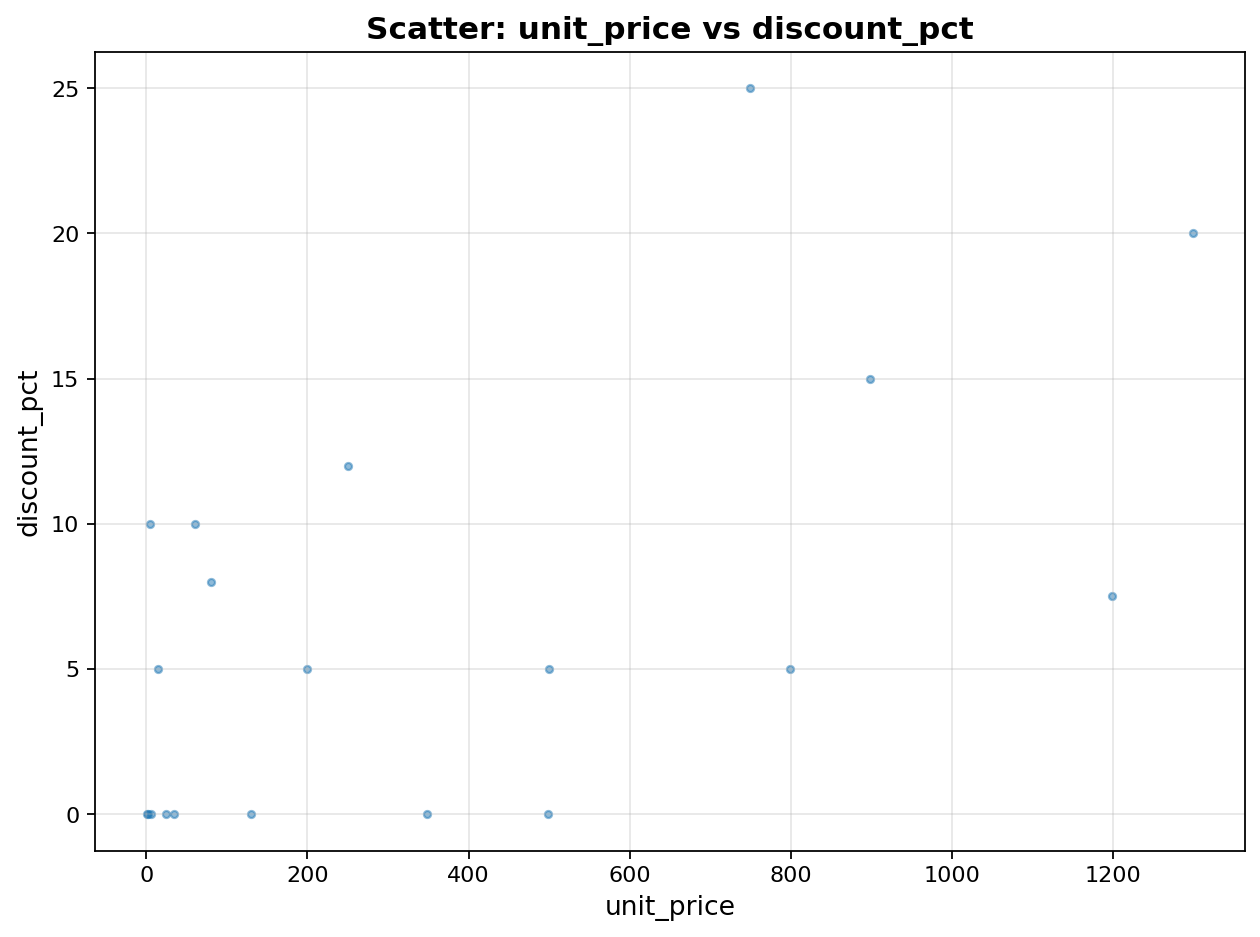

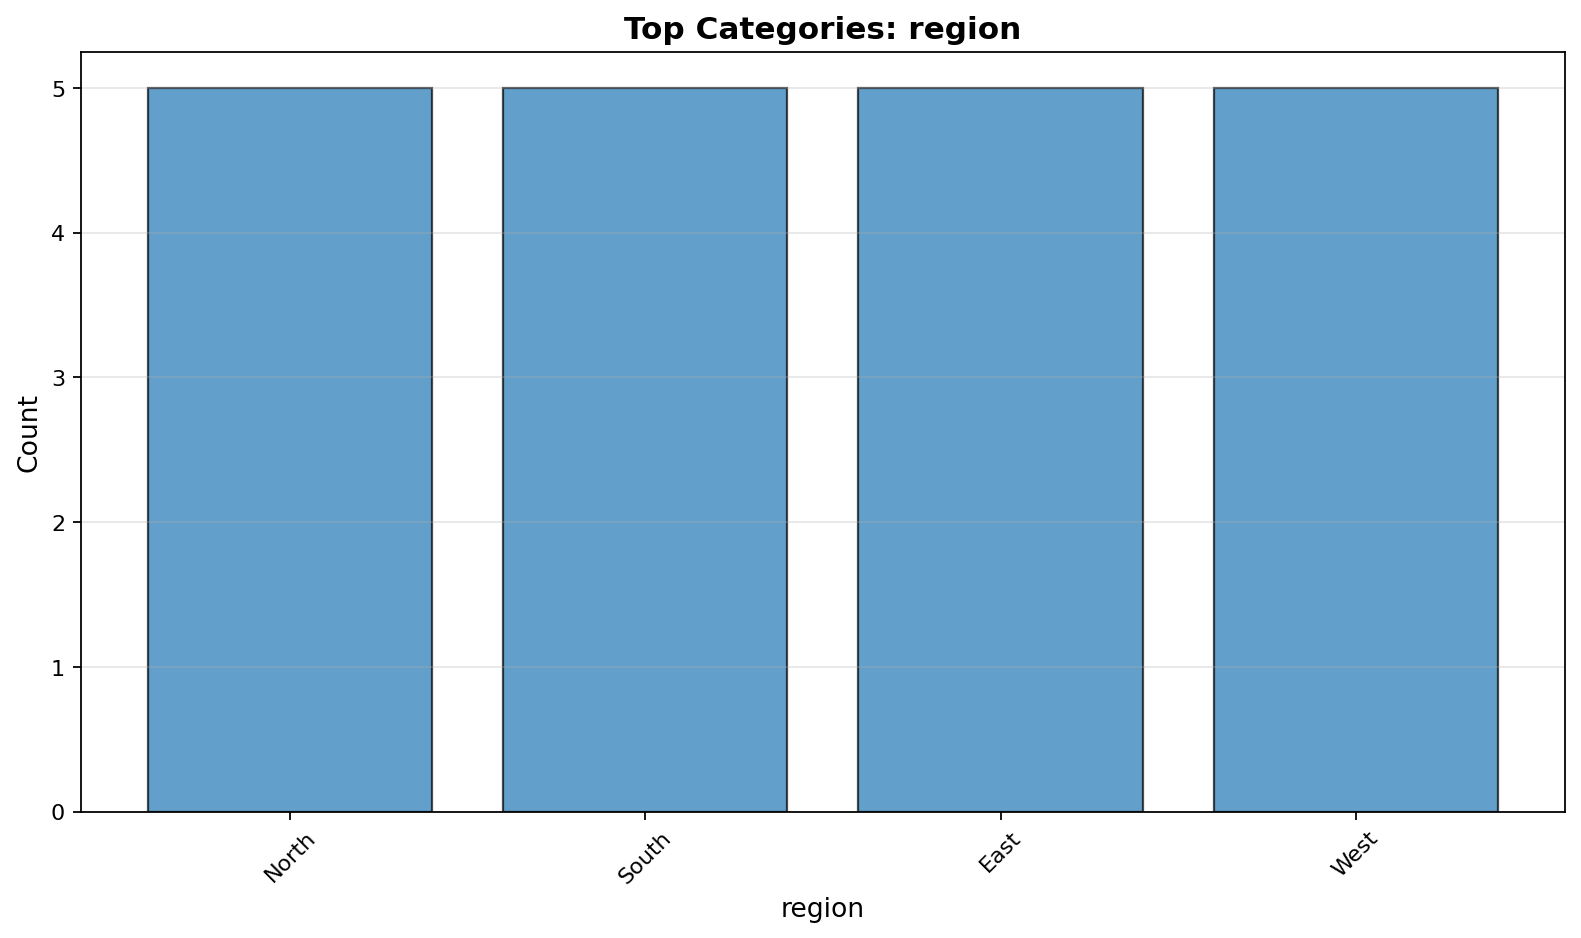

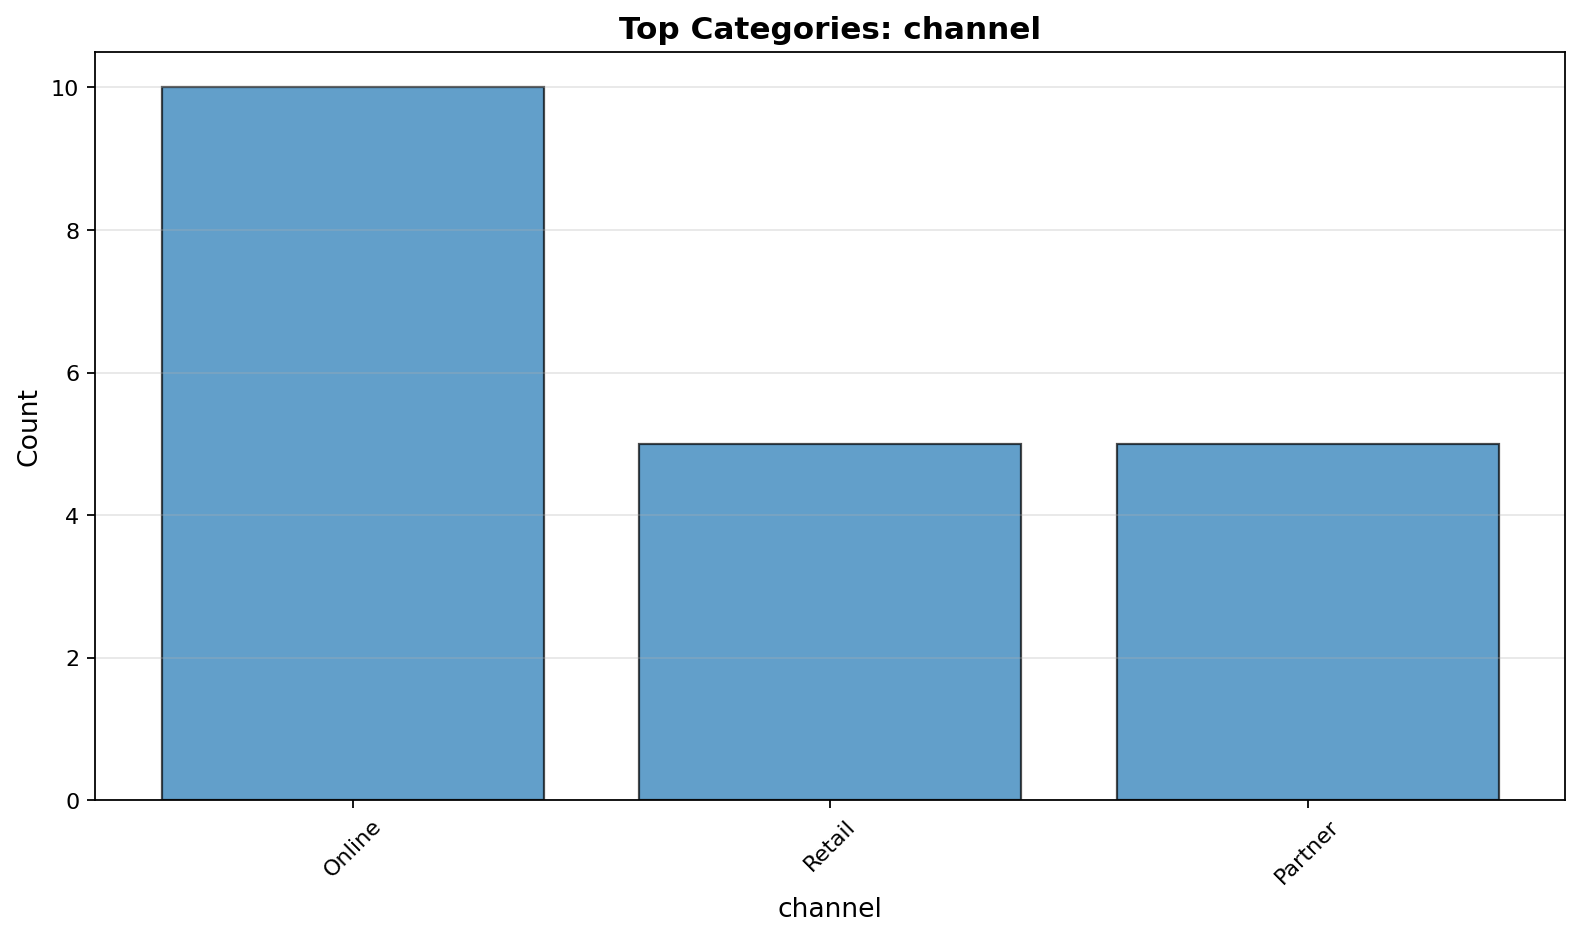

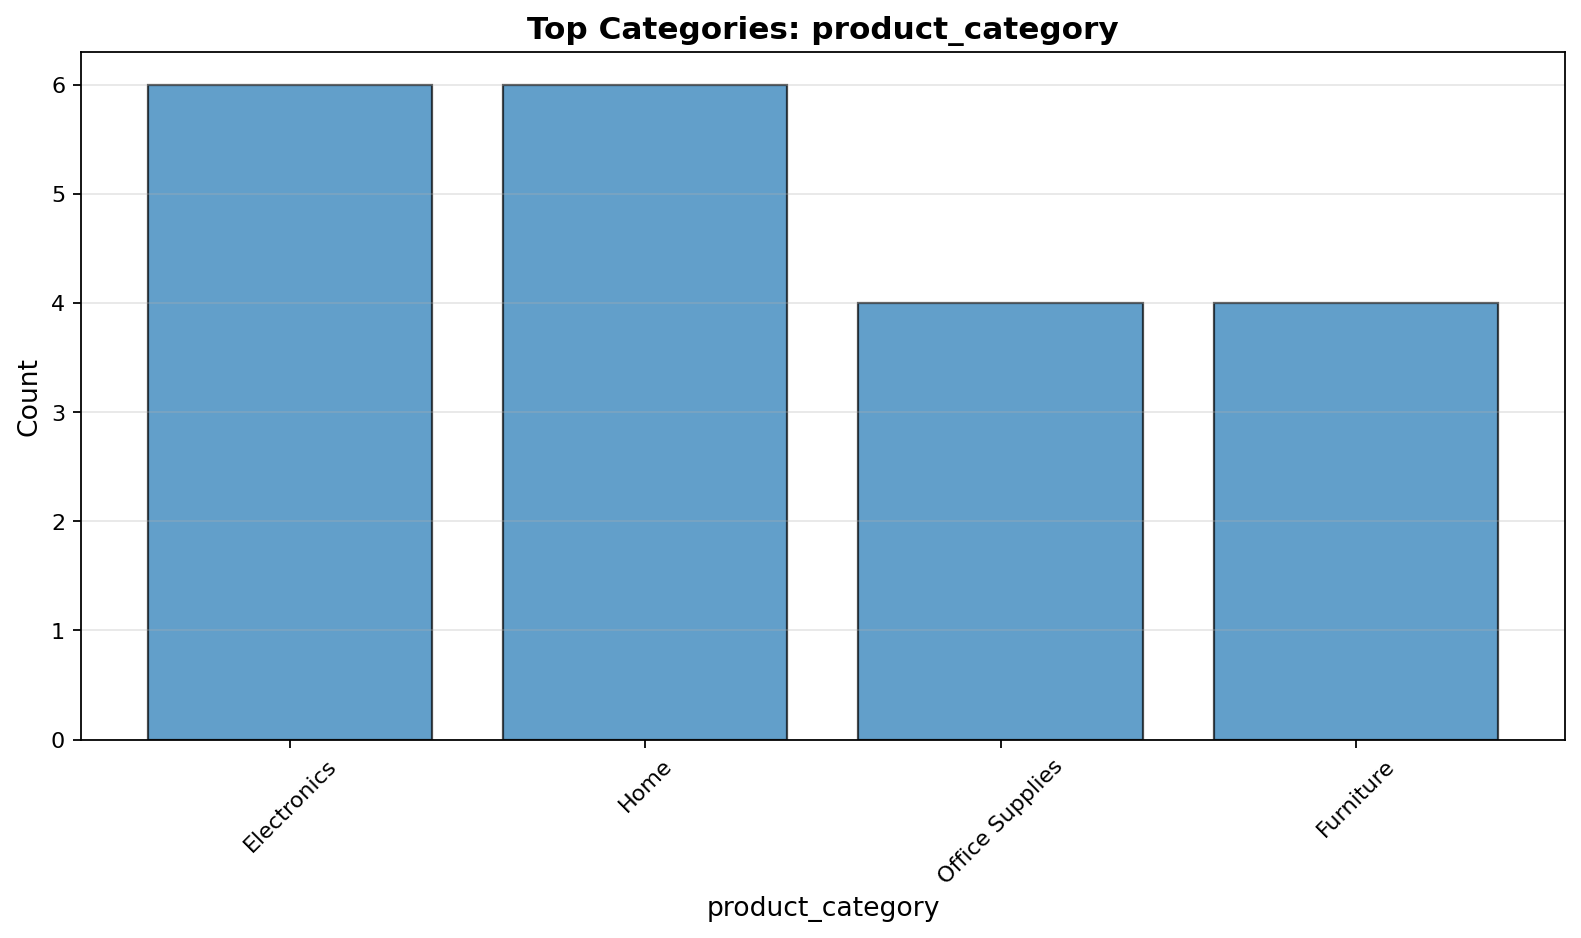

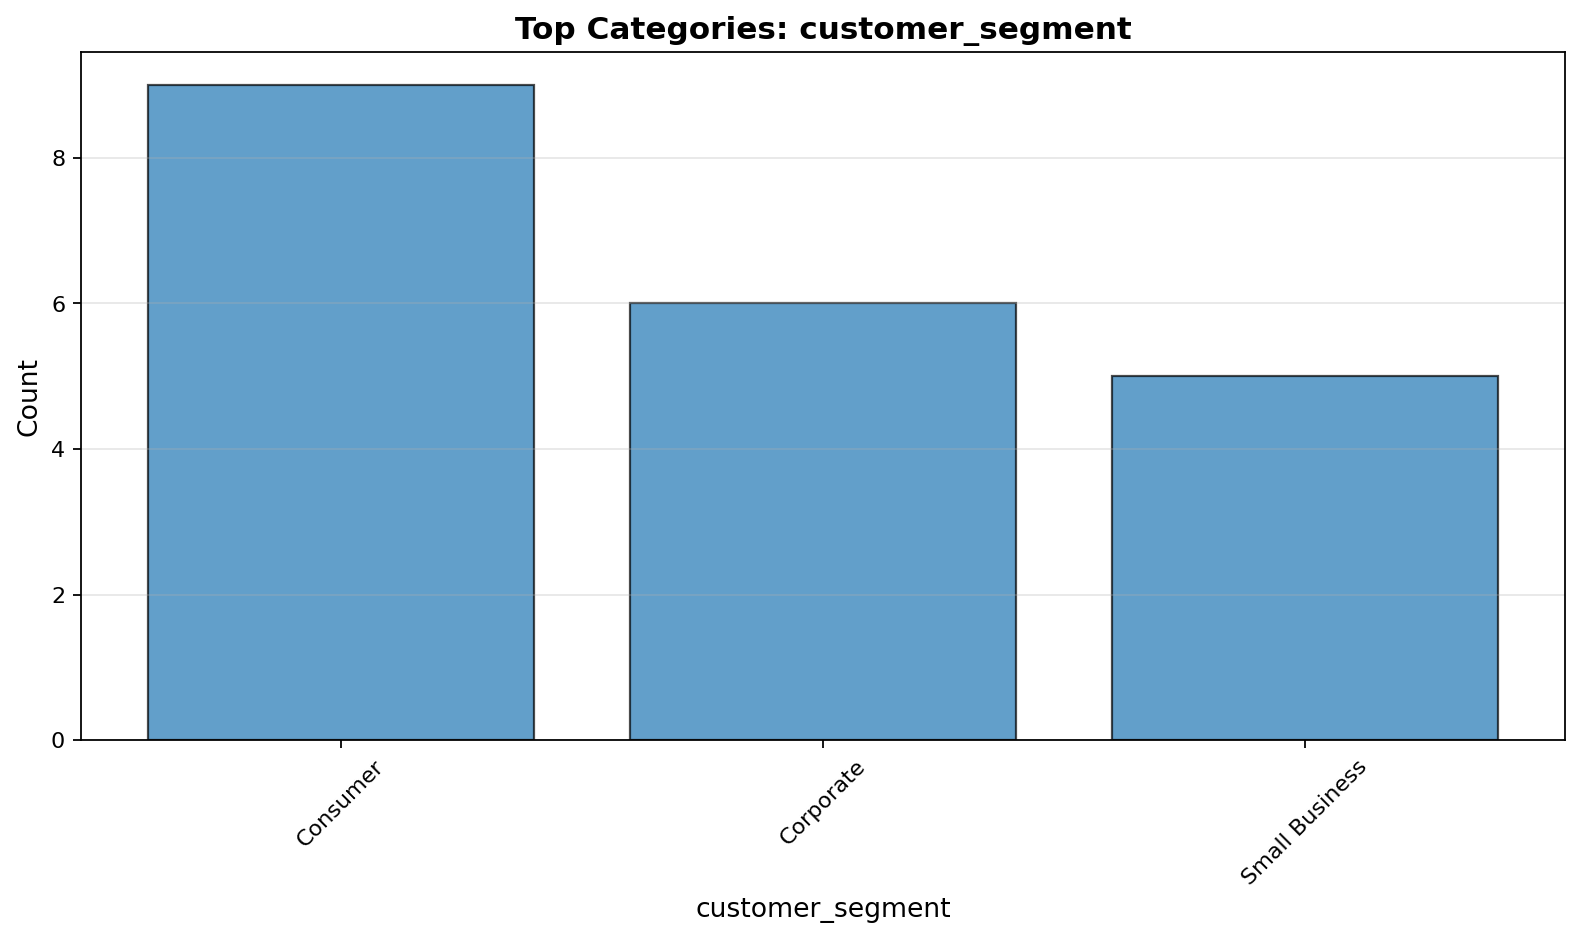

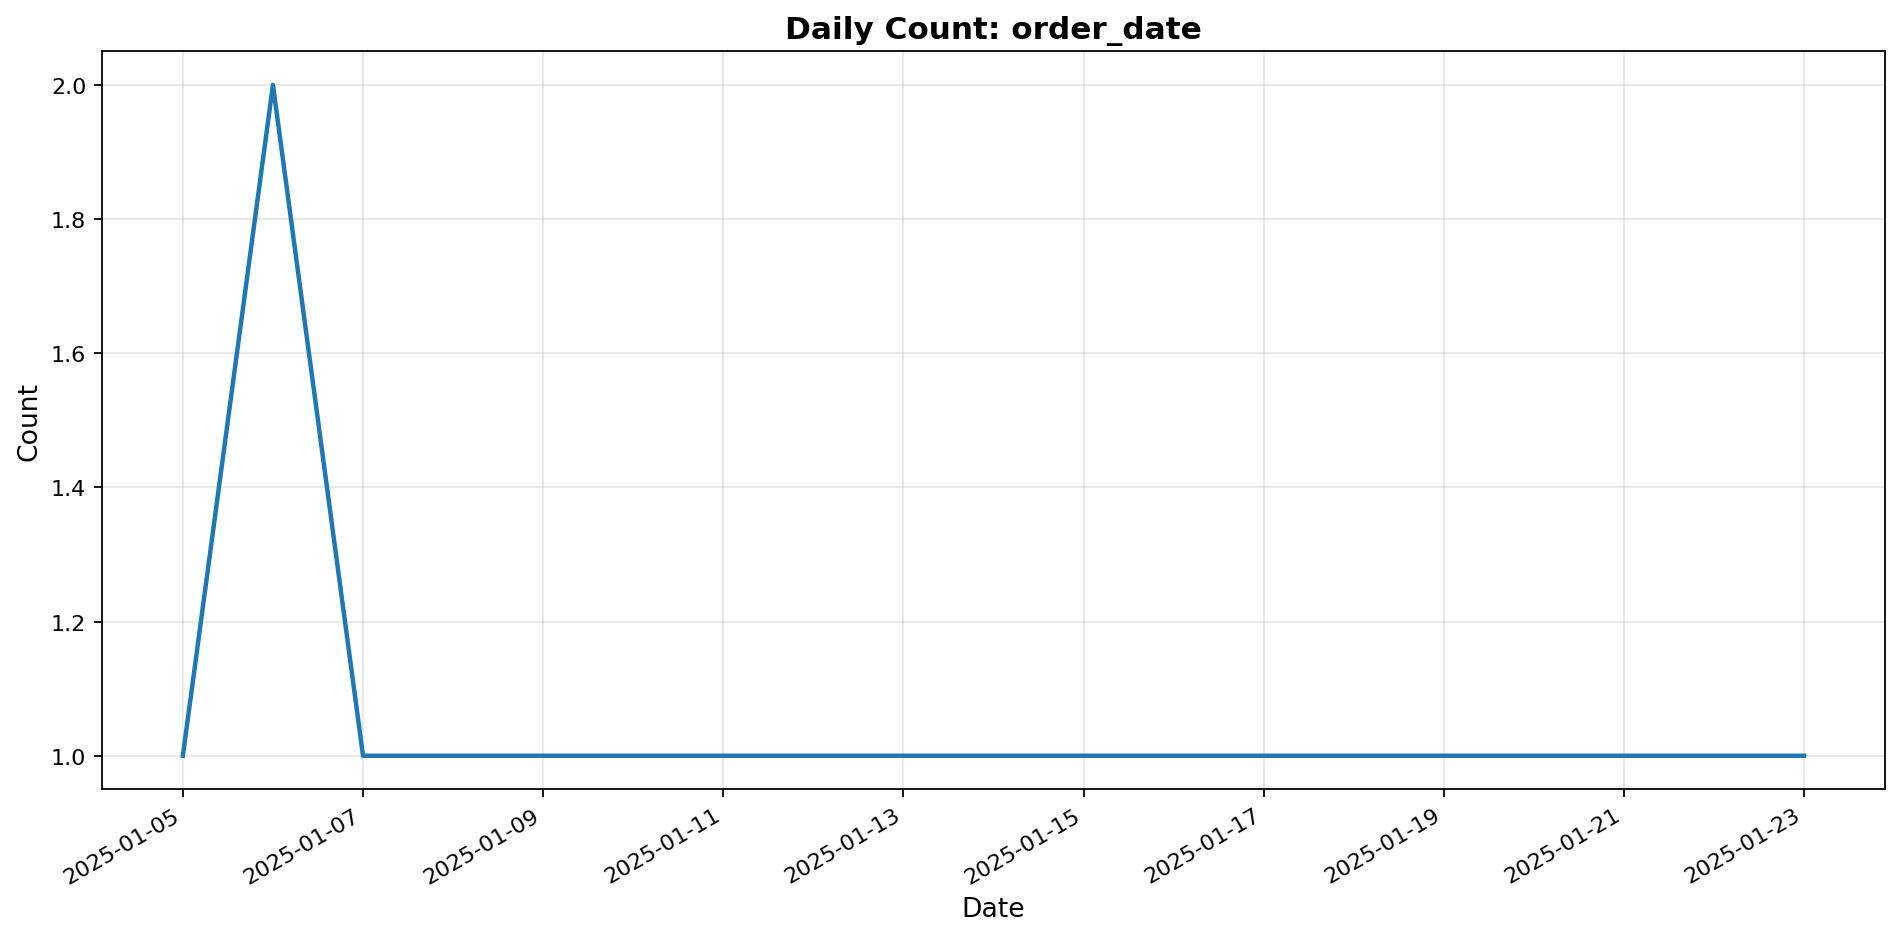

🤖 Generating AI insights...
✓ Generated 7 insights
💾 Saving report...
✓ Report saved → /content/output/eda_report.json

✅ EDA COMPLETE
📁 Output directory: /content/output
📄 Report: /content/output/eda_report.json
📊 Charts: /content/output/charts


In [1]:
from __future__ import annotations

import argparse
import json
import os
import tempfile
import gc
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, TypedDict, cast

import matplotlib
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402


# =========================================================
# NOTEBOOK CONFIG (EDIT THESE IN COLAB)
# =========================================================
NOTEBOOK_MODE = True  # set False to use CLI
DISPLAY_CHARTS_IN_NOTEBOOK = True  # show generated charts inline (also saved to files)
INPUT_PATH = "/content/sample_data.csv"
OUTPUT_DIR = "/content/output"  # Main output directory
OUTPUT_PATH = "/content/output/eda_report.json"  # Report location
CHARTS_SUBDIR = "charts"  # Subdirectory for charts within OUTPUT_DIR
# =========================================================


class EDAState(TypedDict, total=False):
    input_path: str
    output_path: str
    output_dir: str
    charts_dir: str
    notebook_mode: bool
    display_charts: bool

    df: pd.DataFrame
    dataset_format: str

    dataset_overview: Dict[str, Any]
    data_quality: Dict[str, Any]
    statistics: Dict[str, Any]
    visual_analysis: Dict[str, Any]
    insights: Dict[str, Any]

    report: Dict[str, Any]
    metadata: Dict[str, Any]


SUPPORTED_SUFFIXES: Tuple[str, ...] = (".csv", ".xlsx", ".json")
DEFAULT_MODEL: str = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
MAX_ROWS_FOR_CORRELATION: int = 50000  # Memory optimization
CHUNK_SIZE: int = 10000  # For large file processing


# -----------------------------
# Utilities
# -----------------------------
def _utc_now_iso() -> str:
    """Get current UTC timestamp in ISO format."""
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def _fail(message: str) -> None:
    """Raise runtime error with custom message."""
    raise RuntimeError(message)


def _set_openai_key_from_colab_if_available() -> None:
    """Attempt to load OpenAI key from Colab secrets."""
    try:
        from google.colab import userdata  # type: ignore

        key = userdata.get("OPENAI_API_KEY")
        if isinstance(key, str) and key.strip():
            os.environ["OPENAI_API_KEY"] = key.strip()
    except Exception:
        pass


def _detect_environment_api_key() -> Optional[str]:
    """Detect OpenAI API key from Colab secrets or environment."""
    # Colab secret (if present)
    try:
        from google.colab import userdata  # type: ignore

        key = userdata.get("OPENAI_API_KEY")
        if isinstance(key, str) and key.strip():
            return key.strip()
    except Exception:
        pass

    # Local .env / env var
    try:
        load_dotenv(override=False)
    except Exception:
        pass

    k2 = os.getenv("OPENAI_API_KEY")
    if isinstance(k2, str) and k2.strip():
        return k2.strip()
    return None


def _infer_dataset_format(path: Path) -> str:
    """Infer dataset format from file extension."""
    suffix = path.suffix.lower()
    if suffix in SUPPORTED_SUFFIXES:
        return suffix
    _fail(f"Unsupported input format '{suffix}'. Supported: {', '.join(SUPPORTED_SUFFIXES)}.")
    return ""


def _load_dataframe(input_path: str) -> Tuple[pd.DataFrame, str]:
    """Load dataframe from CSV, Excel, or JSON file with memory optimization."""
    p = Path(input_path).expanduser().resolve()
    if not p.exists() or not p.is_file():
        _fail(f"Input path does not exist or is not a file: {p}")

    fmt = _infer_dataset_format(p)
    try:
        if fmt == ".csv":
            # Memory optimization: use optimal dtypes
            df = pd.read_csv(p, low_memory=False)
        elif fmt == ".xlsx":
            df = pd.read_excel(p, engine='openpyxl')
        elif fmt == ".json":
            # Try JSON Lines, then normal JSON
            try:
                df = pd.read_json(p, lines=True)
            except ValueError:
                df = pd.read_json(p)
        else:
            _fail(f"Unsupported input format '{fmt}'. Supported: {', '.join(SUPPORTED_SUFFIXES)}.")
            df = pd.DataFrame()
    except Exception as e:
        _fail(f"Failed to load dataset: {e}")
        df = pd.DataFrame()

    if df.empty:
        _fail("Loaded dataset is empty. Provide a non-empty CSV/Excel/JSON dataset.")

    # Memory optimization: downcast numeric types where possible
    df = _optimize_dataframe_memory(df)

    return df, fmt


def _optimize_dataframe_memory(df: pd.DataFrame) -> pd.DataFrame:
    """Optimize dataframe memory usage by downcasting numeric types."""
    for col in df.select_dtypes(include=['int']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    for col in df.select_dtypes(include=['float']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    return df


def _safe_to_datetime(series: pd.Series) -> Tuple[pd.Series, bool]:
    """
    Safely convert a series to datetime, handling timezone-aware conversions.
    Returns (converted_series, is_datetime_bool).

    FIXED: Proper timezone-aware to timezone-naive conversion.
    """
    # Already datetime? Handle timezone if present
    if pd.api.types.is_datetime64_any_dtype(series):
        s = series.copy()
        # Check if timezone-aware using isinstance instead of deprecated function
        if isinstance(s.dtype, pd.DatetimeTZDtype):
            # Convert to UTC then remove timezone
            s = s.dt.tz_convert('UTC').dt.tz_localize(None)
        return s, True

    # Try to convert string/object types to datetime
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        try:
            # First attempt: Try ISO8601 format (suppresses warnings)
            s = pd.to_datetime(series, errors='coerce', format='ISO8601')
            # Convert timezone-aware to naive
            if isinstance(s.dtype, pd.DatetimeTZDtype):
                s = s.dt.tz_convert('UTC').dt.tz_localize(None)
        except (TypeError, ValueError):
            # Second attempt: Try with UTC (may show warning)
            try:
                import warnings
                with warnings.catch_warnings():
                    warnings.filterwarnings('ignore', category=UserWarning, message='.*Could not infer format.*')
                    s = pd.to_datetime(series, errors='coerce', utc=True)
                    # Convert timezone-aware to naive
                    if isinstance(s.dtype, pd.DatetimeTZDtype):
                        s = s.dt.tz_convert('UTC').dt.tz_localize(None)
            except Exception:
                # Third attempt: Basic conversion
                try:
                    s = pd.to_datetime(series, errors='coerce')
                except Exception:
                    return series, False

        # Check if conversion was successful (>=80% non-null)
        non_null = int(s.notna().sum())
        total = int(len(s))

        if total > 0 and (non_null / total) >= 0.8:
            return s, True

    return series, False


def _to_jsonable(x: Any) -> Any:
    """Convert numpy/pandas objects to JSON-serializable types recursively."""
    if x is None:
        return None
    if isinstance(x, (str, int, float, bool)):
        return x
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        # Handle NaN and Inf
        val = float(x)
        if np.isnan(val) or np.isinf(val):
            return None
        return val
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, (pd.Timestamp, datetime)):
        try:
            return x.isoformat()
        except Exception:
            return str(x)
    if isinstance(x, dict):
        return {str(k): _to_jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_to_jsonable(v) for v in x]
    # Fallback
    return str(x)


def _safe_filename(name: str) -> str:
    """Create safe filename from column name."""
    keep = []
    for ch in str(name):
        keep.append(ch if (ch.isalnum() or ch in ("_", "-")) else "_")
    cleaned = "".join(keep).strip("_")
    return cleaned[:80] if cleaned else "col"


def _save_plot(fig: plt.Figure, out_dir: Path, filename: str) -> str:
    """Save matplotlib figure and close it to free memory."""
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    # Force garbage collection
    gc.collect()
    return str(out_path)


def _maybe_display_images(paths: List[str], enabled: bool) -> None:
    """Display images in notebook if enabled."""
    if not enabled:
        return
    try:
        from IPython.display import Image, display  # type: ignore

        for p in paths:
            display(Image(filename=p))
    except Exception:
        # If display isn't available, do nothing (still saved to disk).
        return


# -----------------------------
# Graph Nodes
# -----------------------------
def load_data_node(state: EDAState) -> EDAState:
    """Load dataset from file."""
    input_path = state.get("input_path")
    if not isinstance(input_path, str) or not input_path.strip():
        _fail("Missing input_path.")

    df, fmt = _load_dataframe(input_path.strip())

    # Log memory usage
    memory_mb = df.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"✓ Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns ({memory_mb:.2f} MB)")

    return {**state, "df": df, "dataset_format": fmt}


def _column_type_summary(df: pd.DataFrame) -> Dict[str, Any]:
    """Analyze and categorize column types with datetime conversion."""
    inferred: Dict[str, str] = {}
    datetime_cols: List[str] = []
    numeric_cols: List[str] = []
    categorical_cols: List[str] = []
    boolean_cols: List[str] = []
    other_cols: List[str] = []

    for col in df.columns:
        s = df[col]

        # Try datetime conversion first
        s2, is_dt = _safe_to_datetime(s)
        if is_dt:
            df[col] = s2
            datetime_cols.append(str(col))
            inferred[str(col)] = "datetime"
            continue

        # Check other types
        if pd.api.types.is_bool_dtype(s):
            boolean_cols.append(str(col))
            inferred[str(col)] = "boolean"
        elif pd.api.types.is_numeric_dtype(s):
            numeric_cols.append(str(col))
            inferred[str(col)] = "numeric"
        elif (
            isinstance(s.dtype, pd.CategoricalDtype)
            or pd.api.types.is_object_dtype(s)
            or pd.api.types.is_string_dtype(s)
        ):
            categorical_cols.append(str(col))
            inferred[str(col)] = "categorical"
        else:
            other_cols.append(str(col))
            inferred[str(col)] = "other"

    return {
        "inferred_types": inferred,
        "numeric_columns": numeric_cols,
        "categorical_columns": categorical_cols,
        "datetime_columns": datetime_cols,
        "boolean_columns": boolean_cols,
        "other_columns": other_cols,
    }


def stats_generator_node(state: EDAState) -> EDAState:
    """Generate comprehensive statistics for the dataset."""
    df = state.get("df")
    if not isinstance(df, pd.DataFrame):
        _fail("Internal error: df missing in stats node.")

    print("⚙ Generating statistics...")

    df_local = df.copy()
    type_summary = _column_type_summary(df_local)

    preview_rows = min(5, len(df_local))
    sample_rows = (
        df_local.head(preview_rows)
        .where(pd.notna(df_local.head(preview_rows)), None)
        .to_dict(orient="records")
    )

    dataset_overview = {
        "format": state.get("dataset_format"),
        "columns": [str(c) for c in df_local.columns],
        "column_types": type_summary["inferred_types"],
        "sample_rows": _to_jsonable(sample_rows),
    }

    # Data quality metrics
    missing_by_col = df_local.isna().sum().to_dict()
    missing_pct_by_col = (df_local.isna().mean() * 100.0).round(3).to_dict()
    duplicate_rows = int(df_local.duplicated().sum())

    # Outliers (IQR) on numeric columns only (exclude booleans)
    outliers_iqr: Dict[str, int] = {}
    numeric_cols = [
        c for c in df_local.columns
        if pd.api.types.is_numeric_dtype(df_local[c]) and not pd.api.types.is_bool_dtype(df_local[c])
    ]

    for col in numeric_cols:
        s = df_local[col].dropna()
        if len(s) < 4:
            outliers_iqr[str(col)] = 0
            continue
        q1 = float(s.quantile(0.25))
        q3 = float(s.quantile(0.75))
        iqr = q3 - q1
        if iqr == 0.0:
            outliers_iqr[str(col)] = 0
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers_iqr[str(col)] = int(((s < lower) | (s > upper)).sum())

    data_quality = {
        "missing_values": {
            "by_column": {str(k): int(v) for k, v in missing_by_col.items()},
            "percent_by_column": {str(k): float(v) for k, v in missing_pct_by_col.items()},
            "total_missing_cells": int(df_local.isna().sum().sum()),
        },
        "duplicates": {"duplicate_rows": duplicate_rows},
        "outliers_iqr": outliers_iqr,
    }

    # Statistics
    stats: Dict[str, Any] = {}
    if numeric_cols:
        desc = df_local[numeric_cols].describe(include=[np.number]).T
        stats["numeric"] = _to_jsonable(desc.replace({np.nan: None}).to_dict(orient="index"))

        # Memory-optimized correlation (sample if dataset is large)
        if len(numeric_cols) >= 2:
            if len(df_local) > MAX_ROWS_FOR_CORRELATION:
                print(f"  → Sampling {MAX_ROWS_FOR_CORRELATION:,} rows for correlation (dataset too large)")
                df_sample = df_local[numeric_cols].sample(n=MAX_ROWS_FOR_CORRELATION, random_state=42)
                corr = df_sample.corr(numeric_only=True).round(6)
            else:
                corr = df_local[numeric_cols].corr(numeric_only=True).round(6)
            stats["correlation_pearson"] = _to_jsonable(corr.replace({np.nan: None}).to_dict())
        else:
            stats["correlation_pearson"] = {}
    else:
        stats["numeric"] = {}
        stats["correlation_pearson"] = {}

    # Categorical statistics
    cat_cols = [c for c, t in type_summary["inferred_types"].items() if t == "categorical"]
    cat_summary: Dict[str, Any] = {}
    for col in cat_cols:
        s = df_local[col].astype("string")
        vc = s.value_counts(dropna=True)
        top_n = min(10, len(vc))
        cat_summary[str(col)] = {
            "unique": int(s.nunique(dropna=True)),
            "top_values": [{"value": str(idx), "count": int(cnt)} for idx, cnt in vc.head(top_n).items()],
        }
    stats["categorical"] = _to_jsonable(cat_summary)

    # Datetime statistics
    dt_cols = [c for c, t in type_summary["inferred_types"].items() if t == "datetime"]
    dt_summary: Dict[str, Any] = {}
    for col in dt_cols:
        s = cast(pd.Series, df_local[col]).dropna()
        if s.empty:
            dt_summary[str(col)] = {"min": None, "max": None, "non_null": 0}
        else:
            # Ensure timezone-naive for serialization
            min_val = pd.Timestamp(s.min())
            max_val = pd.Timestamp(s.max())
            dt_summary[str(col)] = {
                "min": min_val.isoformat(),
                "max": max_val.isoformat(),
                "non_null": int(s.shape[0]),
            }
    stats["datetime"] = _to_jsonable(dt_summary)

    print(f"✓ Statistics generated for {len(df_local.columns)} columns")

    return {
        **state,
        "df": df_local,  # keep coerced datetime columns
        "dataset_overview": dataset_overview,
        "data_quality": data_quality,
        "statistics": stats,
    }


def chart_generator_node(state: EDAState) -> EDAState:
    """Generate visualization charts with memory optimization."""
    df = state.get("df")
    if not isinstance(df, pd.DataFrame):
        _fail("Internal error: df missing in chart node.")

    print("📊 Generating visualizations...")

    overview = cast(Dict[str, Any], state.get("dataset_overview", {}))
    inferred = cast(Dict[str, str], overview.get("column_types", {}))
    numeric_cols = [c for c, t in inferred.items() if t == "numeric"]
    cat_cols = [c for c, t in inferred.items() if t == "categorical"]
    dt_cols = [c for c, t in inferred.items() if t == "datetime"]

    # Use permanent output directory instead of temp
    charts_dir = state.get("charts_dir")
    if charts_dir:
        out_dir = Path(charts_dir)
    else:
        # Fallback to temp if charts_dir not provided
        out_dir = Path(tempfile.mkdtemp(prefix="eda_charts_"))

    out_dir.mkdir(parents=True, exist_ok=True)

    charts: List[Dict[str, Any]] = []
    display_paths: List[str] = []

    # 1) Missingness bar chart (top 20)
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if not miss.empty:
        miss = miss.head(20)
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)
        ax.bar([str(i) for i in miss.index], (miss.values * 100.0))
        ax.set_title("Missingness by Column (Top 20)", fontsize=14, fontweight='bold')
        ax.set_xlabel("Column", fontsize=12)
        ax.set_ylabel("Missing (%)", fontsize=12)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis='y', alpha=0.3)
        p = _save_plot(fig, out_dir, "missingness_top20.png")
        charts.append(
            {
                "chart_type": "missingness_bar",
                "columns": [str(c) for c in miss.index],
                "path": p,
                "description": "Percent missing values per column (top 20).",
            }
        )
        display_paths.append(p)

    # 2) Histograms + Boxplots (up to 6 numeric)
    for col in numeric_cols[:6]:
        s = df[col].dropna()
        if s.empty:
            continue

        # Histogram
        fig = plt.figure(figsize=(8, 5))
        ax = fig.add_subplot(1, 1, 1)
        ax.hist(s.to_numpy(), bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(f"Distribution: {col}", fontsize=14, fontweight='bold')
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        p = _save_plot(fig, out_dir, f"hist_{_safe_filename(col)}.png")
        charts.append(
            {
                "chart_type": "histogram",
                "columns": [col],
                "path": p,
                "description": f"Distribution of {col} (30-bin histogram).",
            }
        )
        display_paths.append(p)

        # Boxplot
        fig = plt.figure(figsize=(6, 8))
        ax = fig.add_subplot(1, 1, 1)
        ax.boxplot(s.to_numpy(), vert=True, showfliers=True, patch_artist=True)
        ax.set_title(f"Boxplot: {col}", fontsize=14, fontweight='bold')
        ax.set_ylabel(col, fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        p = _save_plot(fig, out_dir, f"box_{_safe_filename(col)}.png")
        charts.append(
            {
                "chart_type": "boxplot",
                "columns": [col],
                "path": p,
                "description": f"Boxplot for {col} (outliers visible).",
            }
        )
        display_paths.append(p)

    # 3) Correlation heatmap (if >=2 numeric)
    if len(numeric_cols) >= 2:
        # Use sampled correlation if available
        stats = cast(Dict[str, Any], state.get("statistics", {}))
        corr_dict = stats.get("correlation_pearson", {})

        if corr_dict:
            corr = pd.DataFrame(corr_dict)
            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(1, 1, 1)
            im = ax.imshow(corr.to_numpy(), aspect="auto", cmap='coolwarm', vmin=-1, vmax=1)
            ax.set_title("Correlation Heatmap (Pearson)", fontsize=14, fontweight='bold')
            ax.set_xticks(range(len(corr.columns)))
            ax.set_yticks(range(len(corr.index)))
            ax.set_xticklabels(corr.columns, rotation=45, ha="right")
            ax.set_yticklabels(corr.index)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            p = _save_plot(fig, out_dir, "correlation_heatmap.png")
            charts.append(
                {
                    "chart_type": "correlation_heatmap",
                    "columns": list(corr.columns),
                    "path": p,
                    "description": "Pearson correlation heatmap for numeric columns.",
                }
            )
            display_paths.append(p)

            # 4) Scatter for strongest correlation pair
            corr_abs = corr.abs().copy()
            np.fill_diagonal(corr_abs.values, 0.0)
            max_idx = np.unravel_index(np.argmax(corr_abs.values), corr_abs.shape)
            x = list(corr.columns)[int(max_idx[0])]
            y = list(corr.columns)[int(max_idx[1])]

            mask = df[x].notna() & df[y].notna()
            if int(mask.sum()) > 0:
                # Sample if too many points
                if int(mask.sum()) > 5000:
                    sample_mask = df[mask].sample(n=5000, random_state=42).index
                    x_vals = df.loc[sample_mask, x].to_numpy()
                    y_vals = df.loc[sample_mask, y].to_numpy()
                else:
                    x_vals = df.loc[mask, x].to_numpy()
                    y_vals = df.loc[mask, y].to_numpy()

                fig = plt.figure(figsize=(8, 6))
                ax = fig.add_subplot(1, 1, 1)
                ax.scatter(x_vals, y_vals, s=10, alpha=0.5)
                ax.set_title(f"Scatter: {x} vs {y}", fontsize=14, fontweight='bold')
                ax.set_xlabel(x, fontsize=12)
                ax.set_ylabel(y, fontsize=12)
                ax.grid(alpha=0.3)
                p = _save_plot(fig, out_dir, f"scatter_{_safe_filename(x)}__{_safe_filename(y)}.png")
                charts.append(
                    {
                        "chart_type": "scatter_strongest_corr_pair",
                        "columns": [x, y],
                        "path": p,
                        "description": f"Scatter plot for strongest absolute correlation pair: {x} vs {y}.",
                    }
                )
                display_paths.append(p)

    # 5) Top-category bars (up to 6 categorical)
    for col in cat_cols[:6]:
        s = df[col].astype("string")
        vc = s.value_counts(dropna=True)
        if vc.empty:
            continue
        top_n = min(10, len(vc))
        vc = vc.head(top_n)
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)
        ax.bar([str(i) for i in vc.index], vc.to_numpy(), edgecolor='black', alpha=0.7)
        ax.set_title(f"Top Categories: {col}", fontsize=14, fontweight='bold')
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel("Count", fontsize=12)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis='y', alpha=0.3)
        p = _save_plot(fig, out_dir, f"bar_{_safe_filename(col)}.png")
        charts.append(
            {
                "chart_type": "bar_top_categories",
                "columns": [col],
                "path": p,
                "description": f"Top {top_n} category counts for {col}.",
            }
        )
        display_paths.append(p)

    # 6) Daily count time series (first datetime column)
    if dt_cols:
        dt_col = dt_cols[0]
        s = df[dt_col].dropna()
        if not s.empty:
            counts = s.dt.floor("D").value_counts().sort_index()
            if not counts.empty:
                fig = plt.figure(figsize=(12, 6))
                ax = fig.add_subplot(1, 1, 1)
                ax.plot(counts.index.to_numpy(), counts.to_numpy(), linewidth=2)
                ax.set_title(f"Daily Count: {dt_col}", fontsize=14, fontweight='bold')
                ax.set_xlabel("Date", fontsize=12)
                ax.set_ylabel("Count", fontsize=12)
                ax.grid(alpha=0.3)
                fig.autofmt_xdate()
                p = _save_plot(fig, out_dir, f"ts_count_{_safe_filename(dt_col)}.png")
                charts.append(
                    {
                        "chart_type": "time_series_daily_count",
                        "columns": [dt_col],
                        "path": p,
                        "description": f"Daily record counts based on {dt_col}.",
                    }
                )
                display_paths.append(p)

    print(f"✓ Generated {len(charts)} charts → {out_dir}")

    _maybe_display_images(display_paths, enabled=bool(state.get("display_charts", False)))

    visual_analysis: Dict[str, Any] = {
        "charts": charts,
        "chart_storage": {
            "directory": str(out_dir),
            "note": "Charts are saved as image files and referenced by path (not embedded).",
        },
    }

    return {**state, "visual_analysis": _to_jsonable(visual_analysis)}


def _build_llm() -> ChatOpenAI:
    """Build ChatOpenAI instance with proper configuration."""
    api_key = _detect_environment_api_key()
    if not api_key:
        _fail("OPENAI_API_KEY is missing. Set it in Colab Secrets as OPENAI_API_KEY or in .env locally.")

    # Pass key explicitly to avoid env propagation issues.
    return ChatOpenAI(
        model=DEFAULT_MODEL,
        temperature=0.0,
        timeout=60,
        max_retries=2,
        openai_api_key=api_key,
        model_kwargs={"response_format": {"type": "json_object"}},
    )


def _compact_for_llm(state: EDAState) -> Dict[str, Any]:
    """Create compact summary for LLM input."""
    overview = cast(Dict[str, Any], state.get("dataset_overview", {}))
    quality = cast(Dict[str, Any], state.get("data_quality", {}))
    stats = cast(Dict[str, Any], state.get("statistics", {}))
    visual = cast(Dict[str, Any], state.get("visual_analysis", {}))
    metadata = cast(Dict[str, Any], state.get("metadata", {}))

    charts = cast(List[Dict[str, Any]], visual.get("charts", []))
    compact_charts = [
        {
            "chart_type": c.get("chart_type"),
            "columns": c.get("columns"),
            "description": c.get("description"),
        }
        for c in charts[:20]
    ]

    # Numeric stats trimmed
    numeric = cast(Dict[str, Any], stats.get("numeric", {}))
    compact_numeric: Dict[str, Any] = {}
    for col, d in list(numeric.items())[:30]:
        if isinstance(d, dict):
            compact_numeric[col] = {
                "count": d.get("count"),
                "mean": d.get("mean"),
                "std": d.get("std"),
                "min": d.get("min"),
                "25%": d.get("25%"),
                "50%": d.get("50%"),
                "75%": d.get("75%"),
                "max": d.get("max"),
            }

    return _to_jsonable(
        {
            "dataset_overview": {
                "format": overview.get("format"),
                "columns": overview.get("columns", []),
                "column_types": overview.get("column_types", {}),
            },
            "data_quality": quality,
            "statistics": {
                "numeric": compact_numeric,
                "categorical": stats.get("categorical", {}),
                "datetime": stats.get("datetime", {}),
                "correlation_pearson": stats.get("correlation_pearson", {}),
            },
            "visual_analysis": {"charts": compact_charts},
            "metadata": metadata,
        }
    )


def _coerce_insights(obj: Any) -> Dict[str, Any]:
    """Validate and coerce insights to expected format."""
    required = ["key_patterns", "anomalies", "business_insights", "recommended_next_steps"]
    out: Dict[str, Any] = {}
    if not isinstance(obj, dict):
        obj = {}
    for k in required:
        v = obj.get(k, [])
        if not isinstance(v, list):
            v = []
        cleaned: List[str] = []
        for item in v:
            if isinstance(item, str) and item.strip():
                cleaned.append(item.strip())
        out[k] = cleaned
    return out


def insight_generator_node(state: EDAState) -> EDAState:
    """Generate AI-powered insights using LLM."""
    print("🤖 Generating AI insights...")

    llm = _build_llm()
    compact = _compact_for_llm(state)

    system_prompt = (
        "You are an expert data analyst. Generate insights strictly from the provided EDA summary JSON.\n"
        "Rules:\n"
        "- Use ONLY the provided summary; do NOT invent values or context.\n"
        "- Output MUST be a single JSON object with EXACT keys:\n"
        '  {"key_patterns": [], "anomalies": [], "business_insights": [], "recommended_next_steps": []}\n'
        "- Each list item MUST be a concise string.\n"
        "- If evidence is insufficient, keep items general and cautious.\n"
        "- Focus on actionable insights and data quality issues.\n"
    )

    user_prompt = (
        "Produce insights based on the EDA summary below.\n"
        "Return ONLY valid JSON (no markdown, no extra keys).\n\n"
        f"{json.dumps(compact, ensure_ascii=False)}"
    )

    try:
        msg = llm.invoke(
            [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ]
        )
        content = msg.content if isinstance(msg.content, str) else ""
        insights = _coerce_insights(json.loads(content)) if content.strip() else _coerce_insights({})
        print(f"✓ Generated {sum(len(v) for v in insights.values())} insights")
    except Exception as e:
        print(f"⚠ LLM insights generation failed: {e}")
        insights = _coerce_insights({})

    return {**state, "insights": insights}


def json_output_node(state: EDAState) -> EDAState:
    """Generate final JSON report."""
    df = state.get("df")
    if not isinstance(df, pd.DataFrame):
        _fail("Internal error: df missing in output node.")

    output_path = state.get("output_path")
    if not isinstance(output_path, str) or not output_path.strip():
        _fail("Missing output_path.")

    print("💾 Saving report...")

    report: Dict[str, Any] = {
        "dataset_overview": state.get("dataset_overview", {}),
        "data_quality": state.get("data_quality", {}),
        "statistics": state.get("statistics", {}),
        "visual_analysis": state.get("visual_analysis", {}),
        "insights": state.get(
            "insights",
            {
                "key_patterns": [],
                "anomalies": [],
                "business_insights": [],
                "recommended_next_steps": [],
            },
        ),
        "metadata": {
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
            "generated_at": _utc_now_iso(),
            "agent_version": "1.0.0-production",
        },
    }

    out_p = Path(output_path).expanduser().resolve()
    out_p.parent.mkdir(parents=True, exist_ok=True)
    with out_p.open("w", encoding="utf-8") as f:
        json.dump(_to_jsonable(report), f, ensure_ascii=False, indent=2)

    print(f"✓ Report saved → {out_p}")

    return {**state, "report": report, "metadata": report["metadata"]}


# -----------------------------
# Graph
# -----------------------------
def build_graph():
    """Build LangGraph workflow."""
    g = StateGraph(EDAState)

    g.add_node("load_data", load_data_node)
    g.add_node("stats_generator", stats_generator_node)
    g.add_node("chart_generator", chart_generator_node)
    g.add_node("insight_generator", insight_generator_node)
    g.add_node("json_output", json_output_node)

    g.set_entry_point("load_data")
    g.add_edge("load_data", "stats_generator")
    g.add_edge("stats_generator", "chart_generator")
    g.add_edge("chart_generator", "insight_generator")
    g.add_edge("insight_generator", "json_output")
    g.add_edge("json_output", END)

    return g.compile()


# -----------------------------
# Entrypoints
# -----------------------------
def run_in_notebook(input_path: str, output_dir: str, output_path: str, charts_subdir: str = "charts") -> None:
    """Run EDA agent in notebook mode."""
    print("=" * 60)
    print("🚀 EDA Agent - Production Grade")
    print("=" * 60)

    _set_openai_key_from_colab_if_available()
    app = build_graph()

    # Create output directory structure
    output_dir_path = Path(output_dir)
    output_dir_path.mkdir(parents=True, exist_ok=True)

    charts_dir_path = output_dir_path / charts_subdir
    charts_dir_path.mkdir(parents=True, exist_ok=True)

    try:
        result = app.invoke(
            {
                "input_path": input_path,
                "output_path": output_path,
                "output_dir": str(output_dir_path),
                "charts_dir": str(charts_dir_path),
                "notebook_mode": True,
                "display_charts": DISPLAY_CHARTS_IN_NOTEBOOK,
            }
        )
        print("\n" + "=" * 60)
        print("✅ EDA COMPLETE")
        print("=" * 60)
        print(f"📁 Output directory: {output_dir_path}")
        print(f"📄 Report: {output_path}")
        print(f"📊 Charts: {charts_dir_path}")
        print("=" * 60)
        return result
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        raise


def main(argv: Optional[List[str]] = None) -> None:
    """CLI entrypoint."""
    parser = argparse.ArgumentParser(
        description="Production-grade EDA agent with LangGraph",
        add_help=True
    )
    parser.add_argument("--input", required=True, type=str, help="Path to dataset (.csv, .xlsx, .json)")
    parser.add_argument("--output", required=True, type=str, help="Path to output JSON report (e.g., report.json)")
    parser.add_argument("--output-dir", type=str, default=None, help="Output directory (defaults to parent dir of --output)")
    parser.add_argument("--charts-subdir", type=str, default="charts", help="Subdirectory name for charts (default: charts)")
    args = parser.parse_args(argv)

    _set_openai_key_from_colab_if_available()
    app = build_graph()

    # Determine output directory
    output_path = Path(args.output)
    if args.output_dir:
        output_dir = Path(args.output_dir)
    else:
        output_dir = output_path.parent

    output_dir.mkdir(parents=True, exist_ok=True)
    charts_dir = output_dir / args.charts_subdir
    charts_dir.mkdir(parents=True, exist_ok=True)

    app.invoke(
        {
            "input_path": args.input,
            "output_path": str(output_path),
            "output_dir": str(output_dir),
            "charts_dir": str(charts_dir),
            "notebook_mode": False,
            "display_charts": False,
        }
    )

    print(f"\n📁 Output directory: {output_dir}")
    print(f"📄 Report: {output_path}")
    print(f"📊 Charts: {charts_dir}")


# =========================================================
# EXECUTION
# =========================================================
if __name__ == "__main__":
    if NOTEBOOK_MODE:
        run_in_notebook(INPUT_PATH, OUTPUT_DIR, OUTPUT_PATH, CHARTS_SUBDIR)
    else:
        main()

In [3]:
# ============================================================
# CELL 8: View Results
# ============================================================
import json

# Load the report
with open(OUTPUT_PATH, 'r') as f:
    report = json.load(f)

# Display key insights
print("=" * 60)
print("📊 EDA REPORT SUMMARY")
print("=" * 60)

metadata = report['metadata']
print(f"\n📈 Dataset: {metadata['rows']:,} rows × {metadata['columns']} columns")
print(f"⏰ Generated: {metadata['generated_at']}")

print("\n🔍 Key Patterns:")
for i, pattern in enumerate(report['insights']['key_patterns'][:5], 1):
    print(f"   {i}. {pattern}")

print("\n⚠️  Anomalies:")
for i, anomaly in enumerate(report['insights']['anomalies'][:5], 1):
    print(f"   {i}. {anomaly}")

print("\n💡 Business Insights:")
for i, insight in enumerate(report['insights']['business_insights'][:5], 1):
    print(f"   {i}. {insight}")

print("\n📋 Recommended Next Steps:")
for i, step in enumerate(report['insights']['recommended_next_steps'][:5], 1):
    print(f"   {i}. {step}")

# Display data quality metrics
dq = report['data_quality']
print(f"\n📊 Data Quality:")
print(f"   Missing cells: {dq['missing_values']['total_missing_cells']:,}")
print(f"   Duplicate rows: {dq['duplicates']['duplicate_rows']:,}")

# Show chart count
charts = report['visual_analysis']['charts']
print(f"\n📈 Generated {len(charts)} visualizations")

📊 EDA REPORT SUMMARY

📈 Dataset: 20 rows × 10 columns
⏰ Generated: 2025-12-16T15:27:20+00:00

🔍 Key Patterns:
   1. Units sold have a wide range with a maximum of 40, indicating potential high demand for certain products.
   2. Unit prices vary significantly, with a maximum of 1299, suggesting a diverse product range.

⚠️  Anomalies:
   1. Three outliers detected in units_sold, which may require further investigation.

💡 Business Insights:
   1. Sales are evenly distributed across regions, indicating a balanced market presence.
   2. Online channel dominates sales, accounting for half of the total orders.

📋 Recommended Next Steps:
   1. Investigate outliers in units_sold to understand their impact on sales performance.
   2. Consider analyzing customer feedback for high unit price products to enhance marketing strategies.

📊 Data Quality:
   Missing cells: 0
   Duplicate rows: 0

📈 Generated 15 visualizations


In [4]:
# ============================================================
# CELL 9: Download Results
# ============================================================
from google.colab import files

# Download the JSON report
files.download(OUTPUT_PATH)

# Optional: Download charts as ZIP
import shutil
import os

chart_dir = report['visual_analysis']['chart_storage']['directory']
if os.path.exists(chart_dir):
    # Create ZIP of all charts
    shutil.make_archive('/content/eda_charts', 'zip', chart_dir)
    files.download('/content/eda_charts.zip')
    print("✅ Downloaded charts.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded charts.zip
